# LDA with gensim and spaCy

## Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

folder_path = '/content/drive/MyDrive/DataScience/headlines-topic-modeling/LDA Models/'

Mounted at /content/drive


In [3]:
!pip install -qq gensim
!pip install pyLDAvis -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 61.0 MB/s eta 0:00:00


In [4]:
import numpy as np
import pandas as pd
import math
import time
from tqdm.notebook import tqdm
from IPython.display import display

#sklearn
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

#Gensim
import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel
from gensim.models import Phrases
from gensim.models.phrases import Phraser

#spacy
import spacy
from nltk.corpus import stopwords

#vis
import pyLDAvis
import pyLDAvis.gensim
import matplotlib.pyplot as plt
import pyLDAvis.gensim_models as gensimvis

#pickle
import pickle

#warnings
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

## Preparing the data

In [5]:
pd.set_option('display.max_colwidth', None)
headlines = pd.read_csv('/content/abcnews-date-text.csv')
headlines

,publish_date,headline_text
0,20030219,aba decides against community broadcasting licence
1,20030219,act fire witnesses must be aware of defamation
2,20030219,a g calls for infrastructure protection summit
3,20030219,air nz staff in aust strike for pay rise
4,20030219,air nz strike to affect australian travellers
...,...,...
1244179,20211231,two aged care residents die as state records 2;093
1244180,20211231,victoria records 5;919 new cases and seven deaths
1244181,20211231,wa delays adopting new close contact definition
1244182,20211231,western ringtail possums found badly dehydrated in heatwave


In [6]:
# creating a month bucket for stratification during train/val/test split

headlines['year'] = headlines['publish_date'] // 10000
headlines['month'] = (headlines['publish_date'] // 100) % 100
headlines['months_since_2003'] = (headlines['year'] - 2003) * 12 + headlines['month']
headlines = headlines.drop(['year', 'month'], axis=1)
headlines

,publish_date,headline_text,months_since_2003
0,20030219,aba decides against community broadcasting licence,2
1,20030219,act fire witnesses must be aware of defamation,2
2,20030219,a g calls for infrastructure protection summit,2
3,20030219,air nz staff in aust strike for pay rise,2
4,20030219,air nz strike to affect australian travellers,2
...,...,...,...
1244179,20211231,two aged care residents die as state records 2;093,228
1244180,20211231,victoria records 5;919 new cases and seven deaths,228
1244181,20211231,wa delays adopting new close contact definition,228
1244182,20211231,western ringtail possums found badly dehydrated in heatwave,228


In [7]:
# creating train/test split (test split will be split into val/test)

X_train, X_test_and_val = train_test_split(headlines, train_size=100000, random_state=111, stratify=headlines['months_since_2003'])
X_train = X_train.reset_index()
X_train = X_train.drop('index', axis=1)
X_train

,publish_date,headline_text,months_since_2003
0,20170908,turnbull promises to step up australias engagement in pacific,177
1,20071220,police appeal for safe driving over holiday period,60
2,20060720,fast food worker not put off by shooting,43
3,20111013,readfearn carbon price pulls through anti climate change furor,106
4,20130415,brenton kroen from waikerie,124
...,...,...,...
99995,20190317,tasmanian aboriginal food business spreading culture,195
99996,20101226,sydney to hobart start review,96
99997,20091111,treasurer kevin foley tells 891 of 10m,83
99998,20100113,bumper tourism season,85


In [8]:
# splitting test into val/test split

X_val, X_test = train_test_split(X_test_and_val, train_size=100000, random_state=111, stratify=X_test_and_val['months_since_2003'])
X_val = X_val.reset_index()
X_val = X_val.drop('index', axis=1)
X_val

,publish_date,headline_text,months_since_2003
0,20110208,abbott unveils 2b cuts package,98
1,20100204,metro trains fixes staff pay glitch,86
2,20180602,indigenous elders walk onto mcg reconciliation,186
3,20080524,south african army kills man during unrest,65
4,20070225,crusaders bulls notch wins in south africa,50
...,...,...,...
99995,20130221,floods cyclone bushfires and now drought for,122
99996,20130404,hospital crash accused faces new charges,124
99997,20130313,thieves run down mum in car theft attempt,123
99998,20130829,female cattle exports,128


### Dataset for Post-hoc LDA

In [9]:
phlda_headlines = pd.read_csv('/content/abcnews-date-text.csv')
phlda_headlines['date_actual'] = pd.to_datetime(phlda_headlines['publish_date'], format='%Y%m%d')
phlda_headlines = phlda_headlines.drop(['publish_date'], axis=1)
phlda_headlines['time_bucket'] = phlda_headlines['date_actual'].dt.to_period('M')
phlda_headlines

,headline_text,date_actual,time_bucket
0,aba decides against community broadcasting licence,2003-02-19,2003-02
1,act fire witnesses must be aware of defamation,2003-02-19,2003-02
2,a g calls for infrastructure protection summit,2003-02-19,2003-02
3,air nz staff in aust strike for pay rise,2003-02-19,2003-02
4,air nz strike to affect australian travellers,2003-02-19,2003-02
...,...,...,...
1244179,two aged care residents die as state records 2;093,2021-12-31,2021-12
1244180,victoria records 5;919 new cases and seven deaths,2021-12-31,2021-12
1244181,wa delays adopting new close contact definition,2021-12-31,2021-12
1244182,western ringtail possums found badly dehydrated in heatwave,2021-12-31,2021-12


## Text preprocessing w/ bigrams and trigrams

In [ ]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

In [ ]:
def lemmatization(texts, allowed_postags=["NOUN", "ADJ", "VERB", "ADV"]):
    texts_out = []

    for doc in nlp.pipe(texts, batch_size=2000, n_process=-1):

        new_text = [t.lemma_ for t in doc if t.pos_ in allowed_postags
                    and not t.is_stop and len(t.lemma_) > 2 and t.is_alpha]
        texts_out.append(new_text)

    return texts_out

In [ ]:
data_tokens = lemmatization(X_train['headline_text'])
print(data_tokens[0][0:20])

['turnbull', 'promise', 'step', 'australias', 'engagement']


In [ ]:
bigram = Phrases(data_tokens, min_count=5, threshold=100)
trigram = Phrases(bigram[data_tokens], threshold=100)

bigram_mod = Phraser(bigram)
trigram_mod = Phraser(trigram)

clean_docs = [trigram_mod[bigram_mod[doc]] for doc in data_tokens]

# saving the cleaned docs into google drive

with open(f'{folder_path}clean_docs.pkl', 'wb') as f:
    pickle.dump(clean_docs, f)

## Determining optimal # of topics

### Creating new dictionary

In [ ]:
id2word = corpora.Dictionary(clean_docs)
id2word.filter_extremes(no_below=10, no_above=.4, keep_n=100000)
corpus = [id2word.doc2bow(text) for text in clean_docs]

In [ ]:
id2word.save(f'{folder_path}/headlines_dictionary.dict')

### Using saved dictionary

In [10]:
id2word = corpora.Dictionary.load('/content/drive/MyDrive/DataScience/headlines-topic-modeling/LDA Models/headlines_dictionary.dict')

with open(f'{folder_path}clean_docs.pkl', 'rb') as f:
    clean_docs = pickle.load(f)

corpus = [id2word.doc2bow(text) for text in clean_docs]

### Testing k

In [ ]:
topic_range = np.arange(20, 101, 10)
c_measures = ['c_v', 'u_mass', 'c_uci', 'c_npmi']
c_vals = {c_measure: [] for c_measure in c_measures}

progress_bar = tqdm(topic_range, desc="Testing different values of K")

for k in progress_bar:
    progress_bar.set_description(f"Training K={k}")

    lda_topic_range = gensim.models.LdaModel(
        corpus=corpus,
        id2word=id2word,
        num_topics=k,
        random_state=111,
        update_every=1,
        chunksize=10000,
        passes=5,
        alpha='auto',
        eta='auto'
    )

    for m in c_measures:
        if m == 'u_mass':
            cm = CoherenceModel(model=lda_topic_range, corpus=corpus, dictionary=id2word, coherence=m)
        else:
            cm = CoherenceModel(model=lda_topic_range, texts=clean_docs, dictionary=id2word, coherence=m)

        c_vals[m].append(cm.get_coherence())

    latest_scores = {m: f"{c_vals[m][-1]:.4f}" for m in c_measures}
    progress_bar.set_postfix(latest_scores)

print("\n Testing Complete!")

## Visualizing the coherence scores

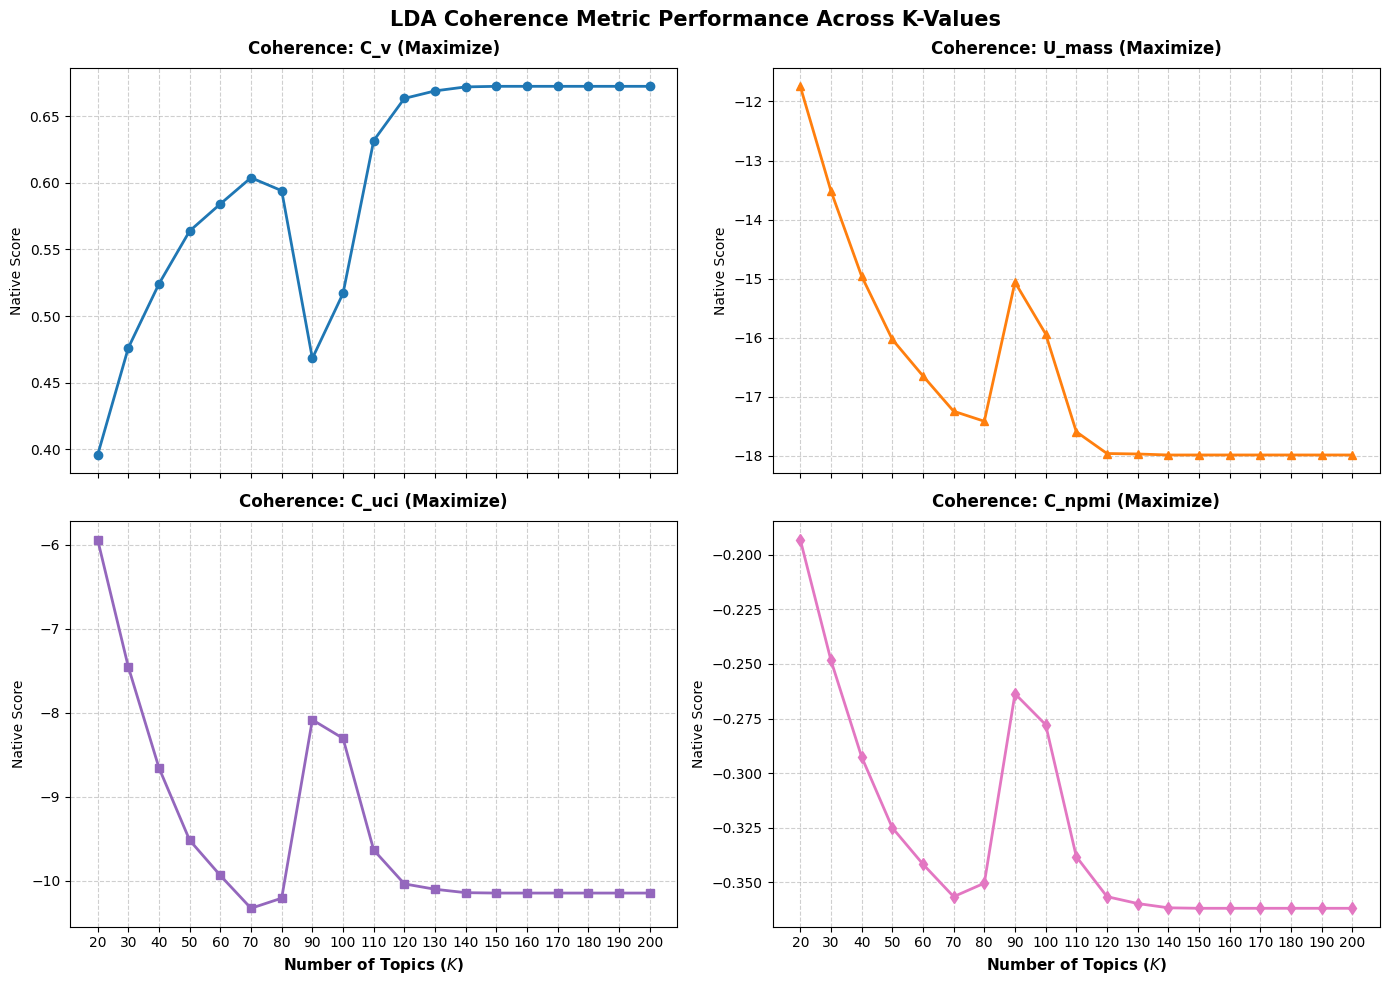

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

plot_configs = {
    'c_v':    {'idx': 0, 'title': 'Coherence: C_v (Maximize)',    'color': '#1f77b4', 'marker': 'o'},
    'u_mass': {'idx': 1, 'title': 'Coherence: U_mass (Maximize)', 'color': '#ff7f0e', 'marker': '^'},
    'c_uci':  {'idx': 2, 'title': 'Coherence: C_uci (Maximize)',  'color': '#9467bd', 'marker': 's'},
    'c_npmi':  {'idx': 3, 'title': 'Coherence: C_npmi (Maximize)',  'color': '#e377c2', 'marker': 'd'}
}

for measure, config in plot_configs.items():
    ax = axes[config['idx']]

    ax.plot(topic_range, c_vals[measure],
            marker=config['marker'],
            color=config['color'],
            linewidth=2,
            linestyle='-')

    ax.set_title(config['title'], fontsize=12, weight='bold', pad=10)
    ax.set_ylabel("Native Score", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.6)

    ax.set_xticks(topic_range)

axes[2].set_xlabel("Number of Topics ($K$)", fontsize=11, weight='bold')
axes[3].set_xlabel("Number of Topics ($K$)", fontsize=11, weight='bold')

plt.suptitle("LDA Coherence Metric Performance Across K-Values", fontsize=15, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

## Training the models

In [ ]:
# 30 topics w/ 20 passes

lda_30 = gensim.models.LdaModel(
          corpus=corpus,
          id2word=id2word,
          num_topics=30,
          random_state = 111,
          update_every=1,
          chunksize=10000,
          passes=20,
          alpha='auto',
          eta='auto'
          )

cm = CoherenceModel(model=lda_30, texts=clean_docs, dictionary=id2word, coherence='c_v')
print(cm.get_coherence())

0.4738388408672721


In [ ]:
# 120 passes

lda_120 = gensim.models.LdaModel(
          corpus=corpus,
          id2word=id2word,
          num_topics=120,
          random_state = 111,
          update_every=1,
          chunksize=10000,
          passes=20,
          alpha='auto',
          eta='auto'
          )

cm = CoherenceModel(model=lda_120, texts=clean_docs, dictionary=id2word, coherence='c_v')
print(cm.get_coherence())

0.6648437122111254


In [ ]:
lda_30.save(f'{folder_path}/news_lda_30_model2.model')

In [ ]:
lda_120.save(f'{folder_path}/news_lda_120_model.model')

### Loading previous models

In [11]:
# 30 topics w/ 10 passes

lda_30_1 = gensim.models.LdaModel.load(f'{folder_path}/news_lda_model.model')

In [12]:
# 70 topics

lda_70 = gensim.models.LdaModel.load(f'{folder_path}/news_lda_70_model.model')

In [13]:
# 30 topics w/ 20 passes, better convergence

lda_30_2 = gensim.models.LdaModel.load(f'{folder_path}/news_lda_30_model2.model')

## Visualizing the trained models

In [15]:
#@title Run this cell to load the Interactive Topic Visualization Dashboard (k=30 w/ 20 passes) { display-mode: "form" }

pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(lda_30_2, corpus, id2word, mds="mmds", R=30)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
11    -0.473082 -0.222066       1        1  6.359829
7      0.086888 -0.315017       2        1  4.666772
12    -0.480693 -0.029957       3        1  4.071698
19     0.363695 -0.274477       4        1  3.948945
4      0.467982 -0.195093       5        1  3.903918
24     0.513185  0.002615       6        1  3.785377
15     0.459161  0.213661       7        1  3.691809
25     0.151403 -0.470034       8        1  3.643386
8     -0.334140 -0.332844       9        1  3.618945
23    -0.240552 -0.431576      10        1  3.581477
10    -0.230318  0.024923      11        1  3.366836
3     -0.479433  0.144077      12        1  3.295132
20    -0.078226 -0.080453      13        1  3.171830
17    -0.105313 -0.384452      14        1  3.159427
5      0.047694  0.495963      15        1  3.158499
2     -0.176633  0.293451      16        1  3.139363
18    -0.395210  0.335308      17        1  3.030674
21    -0.334031 -0.157283      18        1  3.024199
29    -0.024536 -0.501926      19        1  2.943422
26     0.293308 -0.397374      20        1  2.938865
1      0.134081 -0.122283      21        1  2.918601
0      0.189955  0.455691      22        1  2.880833
13    -0.334094  0.167668      23        1  2.860447
9      0.053222  0.233174      24        1  2.838318
6     -0.229775  0.451597      25        1  2.788298
14    -0.068228  0.431500      26        1  2.766264
16     0.214565  0.031497      27        1  2.668009
22     0.388454  0.019028      28        1  2.650130
28     0.295408  0.231212      29        1  2.620423
27     0.325263  0.383472      30        1  2.508275, topic_info=            Term         Freq        Total Category  logprob  loglift
9         police  2869.000000  2869.000000  Default  30.0000  30.0000
135          man  2481.000000  2481.000000  Default  29.0000  29.0000
131          say  2025.000000  2025.000000  Default  28.0000  28.0000
98          plan  1832.000000  1832.000000  Default  27.0000  27.0000
39          fire  1605.000000  1605.000000  Default  26.0000  26.0000
...          ...          ...          ...      ...      ...      ...
1238    unlikely    73.564901    74.544637  Topic30  -4.8133   3.6723
1443  queensland    72.736685    73.716421  Topic30  -4.8246   3.6722
1000      easter    67.262055    68.241791  Topic30  -4.9028   3.6711
3720        rice    65.147786    66.127522  Topic30  -4.9348   3.6706
1471  evacuation    64.646418    65.626154  Topic30  -4.9425   3.6705

[997 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
1053     22  0.997593  aboriginal
445       6  0.997576       abuse
1952     13  0.995377      access
578       1  0.997400    accident
63        1  0.998305      accuse
...     ...       ...         ...
149      19  0.146013        year
250       5  0.996022       young
1114     17  0.994262       youth
1690      7  0.816910        zone
1690     28  0.171551        zone

[1077 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[12, 8, 13, 20, 5, 25, 16, 26, 9, 24, 11, 4, 21, 18, 6, 3, 19, 22, 30, 27, 2, 1, 14, 10, 7, 15, 17, 23, 29, 28])

In [16]:
#@title Run this cell to load the Interactive Topic Visualization Dashboard (k=30) { display-mode: "form" }

pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(lda_30_1, corpus, id2word, mds="mmds", R=30)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
11     0.264053  0.060536       1        1  6.217197
7      0.508125  0.094644       2        1  4.466886
12    -0.247802  0.066940       3        1  4.084082
19    -0.456981 -0.241222       4        1  3.945826
4      0.065353 -0.345895       5        1  3.790003
15    -0.119401 -0.158961       6        1  3.778253
8     -0.293172 -0.203928       7        1  3.660117
24    -0.031982  0.105197       8        1  3.654560
23     0.014379  0.295215       9        1  3.579864
25     0.083669 -0.127138      10        1  3.555828
10     0.474727 -0.158877      11        1  3.369431
2     -0.040745  0.473489      12        1  3.203262
3      0.276967  0.243678      13        1  3.197871
20    -0.372299  0.362222      14        1  3.196260
17     0.117511  0.491618      15        1  3.177093
5     -0.258847  0.293991      16        1  3.135798
18    -0.465400  0.055450      17        1  3.077649
1     -0.445943  0.195539      18        1  3.009383
26     0.421527  0.050538      19        1  2.992088
29    -0.171999 -0.412531      20        1  2.985553
21     0.292116 -0.154982      21        1  2.925989
13     0.222977  0.401361      22        1  2.908140
0      0.404807  0.327094      23        1  2.884828
9     -0.478222 -0.079830      24        1  2.862718
14     0.257179 -0.382185      25        1  2.854253
6     -0.054488 -0.489511      26        1  2.831311
16    -0.314957 -0.394956      27        1  2.708866
22     0.389367 -0.311793      28        1  2.701892
28    -0.176090  0.443350      29        1  2.682756
27     0.135570 -0.499054      30        1  2.562241, topic_info=            Term         Freq        Total Category  logprob  loglift
135          man  2506.000000  2506.000000  Default  30.0000  30.0000
9         police  2907.000000  2907.000000  Default  29.0000  29.0000
131          say  2004.000000  2004.000000  Default  28.0000  28.0000
98          plan  1838.000000  1838.000000  Default  27.0000  27.0000
39          fire  1596.000000  1596.000000  Default  26.0000  26.0000
...          ...          ...          ...      ...      ...      ...
1443  queensland    74.214736    75.195130  Topic30  -4.8258   3.6512
1238    unlikely    72.526621    73.507015  Topic30  -4.8488   3.6509
3720        rice    67.370599    68.350993  Topic30  -4.9225   3.6498
1000      easter    66.807866    67.788260  Topic30  -4.9309   3.6497
1471  evacuation    64.147940    65.128333  Topic30  -4.9715   3.6491

[1013 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
1053     23  0.997404  aboriginal
445       8  0.996297       abuse
1952     14  0.996018      access
578       1  0.996729    accident
63        1  0.998679      accuse
...     ...       ...         ...
149      20  0.148012        year
250       5  0.997230       young
1114     17  0.994328       youth
1690      6  0.819200        zone
1690     28  0.173770        zone

[1189 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[12, 8, 13, 20, 5, 16, 9, 25, 24, 26, 11, 3, 4, 21, 18, 6, 19, 2, 27, 30, 22, 14, 1, 10, 15, 7, 17, 23, 29, 28])

In [17]:
#@title Run this cell to load the Interactive Topic Visualization Dashboard (k=70) { display-mode: "form" }

pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(lda_70, corpus, id2word, mds="mmds", R=30)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
14    -0.121576  0.452296       1        1  2.499522
11     0.114809 -0.502731       2        1  2.432573
2     -0.109435 -0.386381       3        1  2.395622
10     0.539685 -0.005039       4        1  2.333093
7      0.045929  0.274740       5        1  2.098782
...         ...       ...     ...      ...       ...
1     -0.522657  0.050846      66        1  0.932357
69    -0.486269 -0.120178      67        1  0.928110
31    -0.350752 -0.145001      68        1  0.918509
8     -0.280294 -0.432209      69        1  0.912076
62    -0.425794  0.171359      70        1  0.842454

[70 rows x 5 columns], topic_info=              Term         Freq        Total Category  logprob  loglift
135            man  2742.000000  2742.000000  Default  30.0000  30.0000
131            say  2132.000000  2132.000000  Default  29.0000  29.0000
127         charge  1883.000000  1883.000000  Default  28.0000  28.0000
98            plan  1964.000000  1964.000000  Default  27.0000  27.0000
439            win  1469.000000  1469.000000  Default  26.0000  26.0000
...            ...          ...          ...      ...      ...      ...
4221       setback    26.914383    27.997284  Topic70  -4.7277   4.7372
4116          aged    26.859946    27.942847  Topic70  -4.7298   4.7371
2652  preselection    26.041090    27.123992  Topic70  -4.7607   4.7359
2196      boundary    25.978828    27.061729  Topic70  -4.7631   4.7358
2134          bolt    24.709822    25.792723  Topic70  -4.8132   4.7337

[2215 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
3240     47  0.977688    abalone
560      62  0.984832    abandon
1079     62  0.983430   abattoir
1435     57  0.980565  abduction
3892      2  0.896660      abetz
...     ...       ...        ...
250      61  0.997256      young
1114      1  0.996392      youth
575      22  0.990449   zimbabwe
1690     44  0.993510       zone
1286     61  0.973673        zoo

[2239 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[15, 12, 3, 11, 8, 29, 66, 61, 7, 57, 20, 1, 53, 19, 34, 33, 42, 51, 10, 21, 25, 55, 31, 47, 45, 49, 18, 41, 13, 65, 69, 60, 17, 67, 44, 28, 58, 30, 40, 26, 62, 5, 22, 27, 23, 35, 68, 4, 14, 6, 59, 36, 24, 43, 46, 64, 48, 50, 39, 16, 37, 52, 54, 56, 38, 2, 70, 32, 9, 63])

## Model Validation
*   Using perplexity and log-likelihood on a validation set




### Creating the validation corpus

In [ ]:
data_tokens_val = lemmatization(X_val['headline_text'])
print(data_tokens_val[0][0:20])

['unveil', 'cut', 'package']


In [ ]:
bigram = Phrases(data_tokens_val, min_count=5, threshold=100)
trigram = Phrases(bigram[data_tokens_val], threshold=100)

bigram_mod = Phraser(bigram)
trigram_mod = Phraser(trigram)

clean_docs_val = [trigram_mod[bigram_mod[doc]] for doc in data_tokens_val]

with open(f'{folder_path}clean_docs_val.pkl', 'wb') as f:
    pickle.dump(clean_docs_val, f)

In [20]:
with open(f'{folder_path}clean_docs_val.pkl', 'rb') as f:
    clean_docs_val = pickle.load(f)

In [21]:
corpus_val = [id2word.doc2bow(text) for text in clean_docs_val]

### Perplexity and log-likelihood

In [22]:
def eval_fit(model, corpus, model_id="LDA_Model"):
    per_word_log_perpl = model.log_perplexity(corpus)
    perplexity = math.pow(2, -per_word_log_perpl)
    log_likelihood_bound = model.bound(corpus)
    total_words = sum(cnt for doc in corpus for _, cnt in doc)

    return {
        "Model ID": model_id,
        "Total Validation Documents": len(corpus),
        "Total Validation Words": total_words,
        "Total Log-Likelihood": round(log_likelihood_bound, 2),
        "Perplexity (Gensim Bound)": round(perplexity, 2)
    }

In [23]:
validation_records = []

validation_records.append(eval_fit(lda_30_2, corpus_val, model_id="LDA_K30_Run2"))
validation_records.append(eval_fit(lda_30_1, corpus_val, model_id="LDA_K30_Run1"))
validation_records.append(eval_fit(lda_70, corpus_val, model_id="LDA_K70_Final"))

df_eval_dashboard = pd.DataFrame(validation_records).set_index("Model ID")

styled_dashboard = (df_eval_dashboard.style
    .format({
        "Total Validation Documents": "{:,}",
        "Total Validation Words": "{:,}",
        "Total Log-Likelihood": "{:,.2f}",
        "Perplexity (Gensim Bound)": "{:.2f}"
    })
    .set_caption("<b>Validation Set Evaluation Summary Dashboard</b>")
)

display(styled_dashboard)

,Total Validation Documents,Total Validation Words,Total Log-Likelihood,Perplexity (Gensim Bound)
Model ID,,,,
LDA_K30_Run2,"100,000","357,495","-3,049,023.59",369.35
LDA_K30_Run1,"100,000","357,495","-3,083,531.08",394.91
LDA_K70_Final,"100,000","357,495","-5,285,839.05",28246.27


## Post-hoc LDA

### E-step projection, summing and normalizing

In [ ]:
temporal_topic_matrix = {}

for period, group in phlda_headlines.groupby('time_bucket'):
    print(f"Processing bucket: {period} ({len(group):,} headlines)...")

    bow_corpus = [id2word.doc2bow(text.split()) for text in group['headline_text']]

    document_topics = lda_30_2.get_document_topics(bow_corpus, minimum_probability=0.0)

    topic_sums = np.zeros(lda_30_2.num_topics)

    for doc in document_topics:
        for topic_id, weight in doc:
            topic_sums[topic_id] += weight

    temporal_topic_matrix[str(period)] = topic_sums / len(group)

Processing bucket: 2003-02 (2,180 headlines)...
Processing bucket: 2003-03 (6,410 headlines)...
Processing bucket: 2003-04 (6,101 headlines)...
Processing bucket: 2003-05 (6,399 headlines)...
Processing bucket: 2003-06 (6,346 headlines)...
Processing bucket: 2003-07 (6,505 headlines)...
Processing bucket: 2003-08 (6,128 headlines)...
Processing bucket: 2003-09 (5,840 headlines)...
Processing bucket: 2003-10 (6,598 headlines)...
Processing bucket: 2003-11 (5,711 headlines)...
Processing bucket: 2003-12 (5,779 headlines)...
Processing bucket: 2004-01 (5,765 headlines)...
Processing bucket: 2004-02 (5,821 headlines)...
Processing bucket: 2004-03 (6,506 headlines)...
Processing bucket: 2004-04 (5,947 headlines)...
Processing bucket: 2004-05 (5,877 headlines)...
Processing bucket: 2004-06 (6,276 headlines)...
Processing bucket: 2004-07 (6,147 headlines)...
Processing bucket: 2004-08 (6,447 headlines)...
Processing bucket: 2004-09 (5,843 headlines)...
Processing bucket: 2004-10 (6,052 headli

### Creating the time-series matrix

In [ ]:
headlines_trends = pd.DataFrame.from_dict(temporal_topic_matrix, orient='index')
headlines_trends.index = pd.to_datetime(headlines_trends.index)
headlines_trends.sort_index(inplace=True)

headlines_trends.columns = [f"Topic_{i}" for i in range(lda_30_2.num_topics)]

headlines_trends.to_csv("lda_post_hoc_temporal_matrix.csv")

### Preliminary visualization and rolling window smoothing

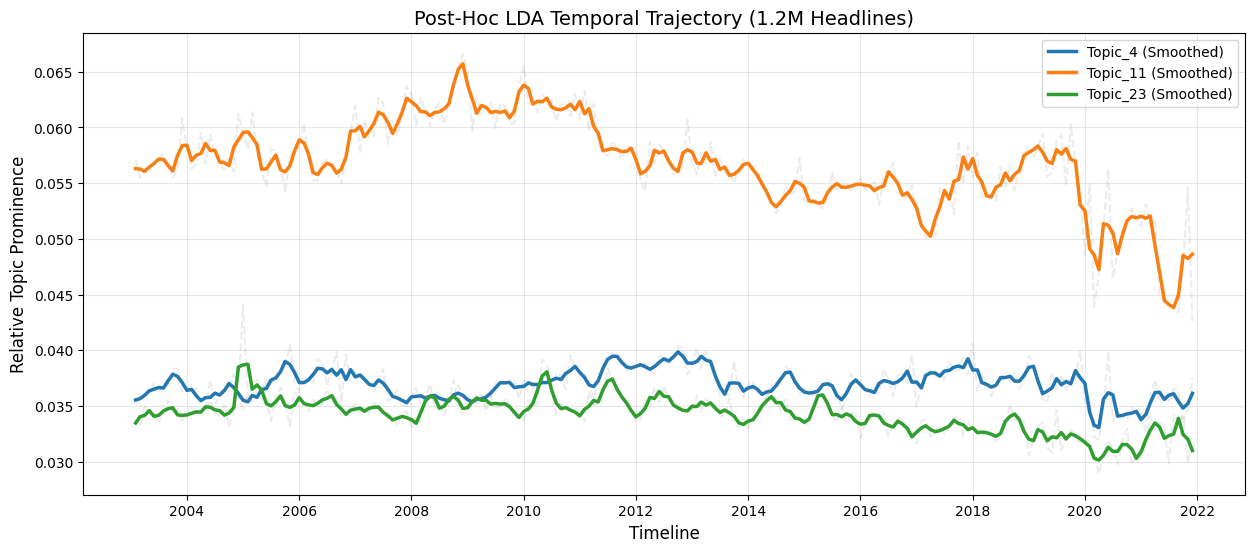

In [ ]:
headlines_smoothed = headlines_trends.rolling(window=3, min_periods=1, center=True).mean()

plt.figure(figsize=(15, 6))

target_topics = ["Topic_4", "Topic_11", "Topic_23"]

for topic in target_topics:
    plt.plot(headlines_smoothed.index, headlines_smoothed[topic], label=f"{topic} (Smoothed)", linewidth=2.5)
    plt.plot(headlines_trends.index, headlines_trends[topic], alpha=0.15, linestyle='--', color='gray')

plt.title("Post-Hoc LDA Temporal Trajectory (1.2M Headlines)", fontsize=14)
plt.ylabel("Relative Topic Prominence", fontsize=12)
plt.xlabel("Timeline", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Labeling the topics

In [ ]:
# visualizing the prevalence (circle size) and similarity (distance between) of
# the topics

pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(lda_30_2, corpus, id2word, mds="mmds", R=30)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
11    -0.473082 -0.222066       1        1  6.358872
7      0.086888 -0.315017       2        1  4.667039
12    -0.480693 -0.029957       3        1  4.071417
19     0.363695 -0.274477       4        1  3.948948
4      0.467982 -0.195093       5        1  3.903924
24     0.513185  0.002615       6        1  3.785380
15     0.459161  0.213661       7        1  3.691976
25     0.151403 -0.470034       8        1  3.643134
8     -0.334140 -0.332844       9        1  3.618685
23    -0.240552 -0.431576      10        1  3.581292
10    -0.230318  0.024923      11        1  3.367394
3     -0.479433  0.144077      12        1  3.295245
20    -0.078226 -0.080453      13        1  3.171828
17    -0.105313 -0.384452      14        1  3.159429
5      0.047694  0.495963      15        1  3.158502
2     -0.176633  0.293451      16        1  3.139723
18    -0.395210  0.335308      17        1  3.031319
21    -0.334031 -0.157283      18        1  3.024219
29    -0.024536 -0.501926      19        1  2.943367
26     0.293308 -0.397374      20        1  2.938672
1      0.134081 -0.122283      21        1  2.918746
0      0.189955  0.455691      22        1  2.880877
13    -0.334094  0.167668      23        1  2.860446
9      0.053222  0.233174      24        1  2.838137
6     -0.229775  0.451597      25        1  2.788300
14    -0.068228  0.431500      26        1  2.766264
16     0.214565  0.031497      27        1  2.668010
22     0.388454  0.019028      28        1  2.650136
28     0.295408  0.231212      29        1  2.620443
27     0.325263  0.383472      30        1  2.508274, topic_info=            Term         Freq        Total Category  logprob  loglift
9         police  2868.000000  2868.000000  Default  30.0000  30.0000
135          man  2481.000000  2481.000000  Default  29.0000  29.0000
131          say  2025.000000  2025.000000  Default  28.0000  28.0000
98          plan  1832.000000  1832.000000  Default  27.0000  27.0000
39          fire  1605.000000  1605.000000  Default  26.0000  26.0000
...          ...          ...          ...      ...      ...      ...
1238    unlikely    73.564887    74.544629  Topic30  -4.8133   3.6723
1443  queensland    72.736671    73.716413  Topic30  -4.8246   3.6722
1000      easter    67.262043    68.241785  Topic30  -4.9028   3.6711
3720        rice    65.147774    66.127516  Topic30  -4.9348   3.6706
1471  evacuation    64.646406    65.626148  Topic30  -4.9425   3.6705

[997 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
1053     22  0.997578  aboriginal
445       6  0.997576       abuse
1952     13  0.995378      access
578       1  0.997550    accident
63        1  0.998455      accuse
...     ...       ...         ...
149      19  0.146022        year
250       5  0.996021       young
1114     17  0.994051       youth
1690      7  0.816880        zone
1690     28  0.171545        zone

[1077 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[12, 8, 13, 20, 5, 25, 16, 26, 9, 24, 11, 4, 21, 18, 6, 3, 19, 22, 30, 27, 2, 1, 14, 10, 7, 15, 17, 23, 29, 28])

In [ ]:
pyldavis_to_gensim_map = vis.topic_order

mapping_records = []
for pyldavis_id, gensim_id in enumerate(pyldavis_to_gensim_map, start=1):
    mapping_records.append({
        "pyLDAvis Circle ID": pyldavis_id,
        "Gensim Topic ID": gensim_id
    })

df_map = pd.DataFrame(mapping_records)

print("=== TOPIC ALIGNMENT TRANSLATION TABLE ===")
print(df_map.to_string(index=False))

=== TOPIC ALIGNMENT TRANSLATION TABLE ===
 pyLDAvis Circle ID  Gensim Topic ID
                  1               12
                  2                8
                  3               13
                  4               20
                  5                5
                  6               25
                  7               16
                  8               26
                  9                9
                 10               24
                 11               11
                 12                4
                 13               21
                 14               18
                 15                6
                 16                3
                 17               19
                 18               22
                 19               30
                 20               27
                 21                2
                 22                1
                 23               14
                 24               10
                 25              

In [ ]:
all_topics = lda_30_2.print_topics(num_topics=-1, num_words=10)

for topic_id, words in all_topics:
    print(f"\nTopic #{topic_id}:")
    print(words)


Topic #0:
0.080*"attack" + 0.066*"continue" + 0.045*"head" + 0.037*"play" + 0.034*"break" + 0.032*"game" + 0.030*"debate" + 0.026*"town" + 0.026*"policy" + 0.024*"highlight"

Topic #1:
0.117*"court" + 0.112*"face" + 0.046*"protest" + 0.034*"rescue" + 0.033*"trump" + 0.033*"hear" + 0.031*"race" + 0.026*"stay" + 0.024*"teacher" + 0.020*"meeting"

Topic #2:
0.067*"market" + 0.058*"end" + 0.036*"question" + 0.036*"melbourne" + 0.033*"future" + 0.031*"drought" + 0.028*"drop" + 0.027*"war" + 0.027*"demand" + 0.025*"victorian"

Topic #3:
0.154*"plan" + 0.068*"hospital" + 0.066*"death" + 0.060*"ban" + 0.031*"announce" + 0.030*"station" + 0.026*"program" + 0.022*"food" + 0.021*"investigation" + 0.019*"discuss"

Topic #4:
0.144*"say" + 0.050*"farmer" + 0.043*"push" + 0.037*"industry" + 0.034*"local" + 0.023*"young" + 0.021*"warning" + 0.020*"use" + 0.020*"award" + 0.020*"loss"

Topic #5:
0.120*"govt" + 0.101*"urge" + 0.038*"act" + 0.035*"threat" + 0.025*"blame" + 0.023*"live" + 0.022*"aussie" +

In [ ]:
topic_names_mapping = {
    0: "Sports & Games",
    1: "Legal & Political Trials",
    2: "Economic & Market Trends",
    3: "Health & Safety Regulations",
    4: "Agricultural Industry News",
    5: "Government Public Alerts",
    6: "Political Leadership & Inquiries",
    7: "Labor & Election Budgets",
    8: "Regional Infrastructure & Business",
    9: "Aviation & Security Logistics",
    10: "Extreme Weather & Seasons",
    11: "Violent Crime & Accidents",
    12: "Financial Market Shifts",
    13: "Energy Costs & Incidents",
    14: "Patient Care & Healthcare Disputes",
    15: "Emergency Fire Responses",
    16: "South Australian Regional News",
    17: "Criminal Investigations & Appeals",
    18: "Public Transit & Traffic Accidents",
    19: "Fatal Accidents & Reports",
    20: "Family Law & Real Estate",
    21: "Flood Relief & Funding",
    22: "Animal & Legal Compliance",
    23: "Resource Mining & Community Taxation",
    24: "Child Welfare & Education",
    25: "Local Council & Water Management",
    26: "Domestic COVID-19 Trajectory",
    27: "Sydney & Indigenous Affairs",
    28: "Court Trials & Sports Matches",
    29: "Corporate & Labor Regulations"
}

headlines_trends.columns = [topic_names_mapping[i] for i in range(lda_30_2.num_topics)]

headlines_trends.to_csv("lda_post_hoc_temporal_matrix_labeled.csv")
print("Saved labeled temporal matrix successfully!")

Saved labeled temporal matrix successfully!


### Visualization of the labeled topics

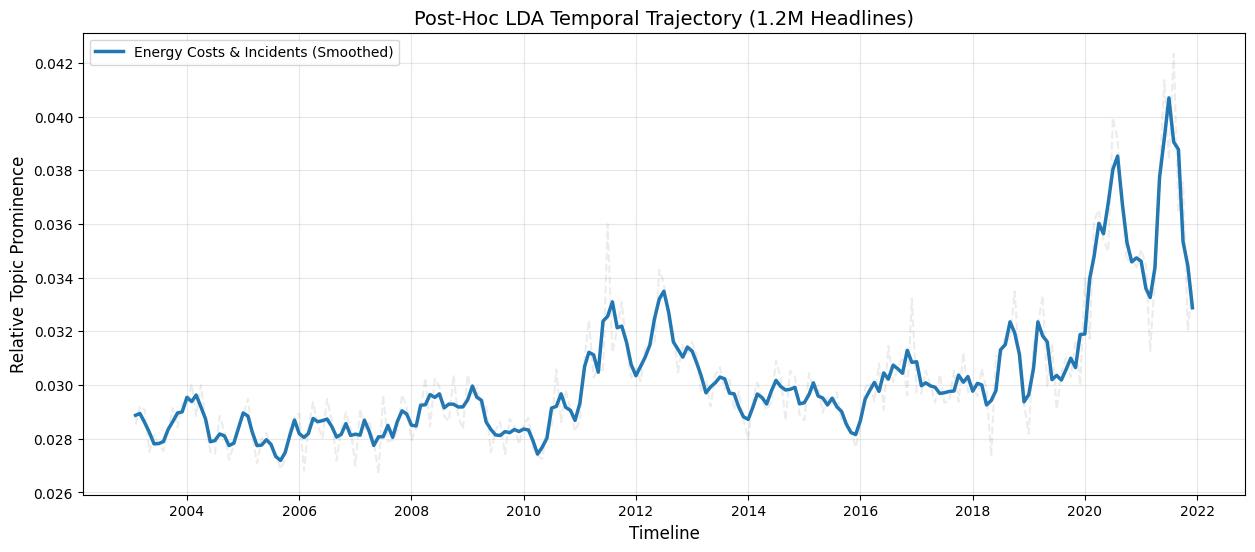

In [ ]:
# topics can be added and removed from target_topics list for visualization

headlines_labeled_smoothed = headlines_trends.rolling(window=3, min_periods=1, center=True).mean()

plt.figure(figsize=(15, 6))

target_topics = ["Energy Costs & Incidents"]

for topic in target_topics:
    plt.plot(headlines_labeled_smoothed.index, headlines_labeled_smoothed[topic], label=f"{topic} (Smoothed)", linewidth=2.5)
    plt.plot(headlines_trends.index, headlines_trends[topic], alpha=0.15, linestyle='--', color='gray')

plt.title("Post-Hoc LDA Temporal Trajectory (1.2M Headlines)", fontsize=14)
plt.ylabel("Relative Topic Prominence", fontsize=12)
plt.xlabel("Timeline", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()